## Importing Liabraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import yfinance as yf

## Downloading Stock Data

In [5]:
# Download stock data
data = yf.download("AAPL", start="2015-01-01", end="2024-12-31")

# Use Closing price
prices = data[['Close']]

print(prices.head())

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2015-01-02  24.214890
2015-01-05  23.532719
2015-01-06  23.534937
2015-01-07  23.864944
2015-01-08  24.781900


## Normalizing Data


In [6]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(prices)

## Create Sequence 30 Days input


In [7]:
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2485, 30, 1)
(2485, 1)


## Train test validation

In [8]:
# Train Test Validation
total_samples = len(X)

train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.2)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(len(X_train), len(X_val), len(X_test))

1739 497 249


## Callbacks

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

## Model A: RNN Model

In [10]:
rnn_model = Sequential([
    SimpleRNN(50, input_shape=(30,1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

c:\Users\User\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

## RNN Training

In [11]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0055 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9988e-04 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1216e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6933e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5932e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4180e-04 - val_loss: 7.5473e-04 - learning_rate: 0.0010
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2987e-04 - val_loss: 6.8867e-04 - learning_rate: 0.0010
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1664e-04 - val_loss: 6.5891e-04 - learning_rate: 0.0010
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2337e-04 - val_loss: 8.0040

## Evaluating RNN

In [12]:
rnn_pred = rnn_model.predict(X_test)

rnn_mse = mean_squared_error(y_test, rnn_pred)
rnn_mae = mean_absolute_error(y_test, rnn_pred)

print("RNN Test MSE:", rnn_mse)
print("RNN Test MAE:", rnn_mae)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
RNN Test MSE: 0.0013101193883694406
RNN Test MAE: 0.02929900442444328


## Model A: LSTM Model 

In [13]:
lstm_model = Sequential([
    LSTM(50, input_shape=(30,1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

c:\Users\User\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Training LSTM 

In [14]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0072 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9448e-04 - val_loss: 9.8638e-04 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6308e-04 - val_loss: 9.5642e-04 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3900e-04 - val_loss: 7.3846e-04 - learning_rate: 0.0010
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3002e-04 - val_loss: 5.8844e-04 - learning_rate: 0.0010
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2902e-04 - val_loss: 7.2066e-04 - learning_rate: 5.0000e-04
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2560e-04 - val_loss: 5.5016e-04 - learning_rate: 5.0000e-04
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2133e-04 - val_loss: 5.4707e-04 - learning_rate: 5.0000e-04
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - los

## Evaluating LSTM

In [15]:
lstm_pred = lstm_model.predict(X_test)

lstm_mse = mean_squared_error(y_test, lstm_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)

print("LSTM Test MSE:", lstm_mse)
print("LSTM Test MAE:", lstm_mae)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
LSTM Test MSE: 0.009648475529852662
LSTM Test MAE: 0.09086198188060904


## Loss Curves

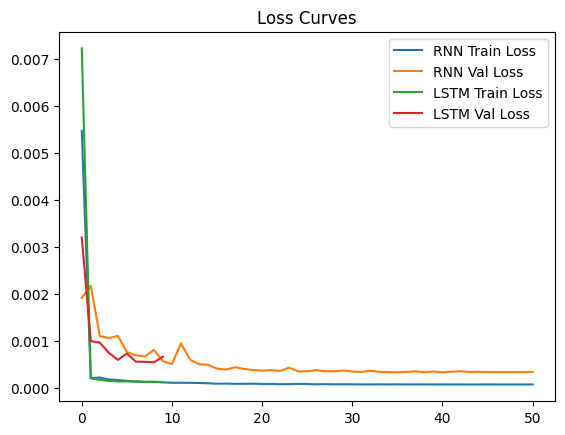

In [16]:
plt.figure()

plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')

plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')

plt.legend()
plt.title("Loss Curves")
plt.show()

## Prediction vs Actual Graph

In [17]:
# Converting back to original prices
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

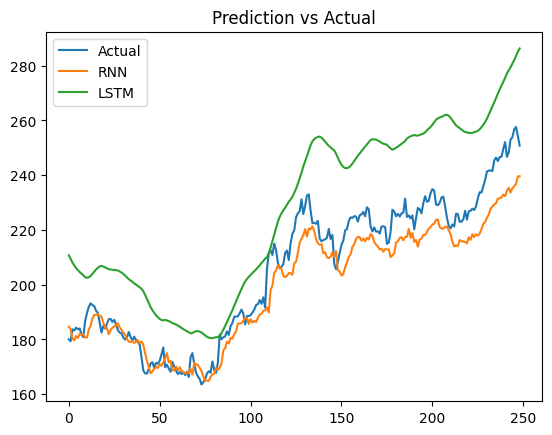

In [18]:
# Plot
plt.figure()

plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred_actual, label="RNN")
plt.plot(lstm_pred_actual, label="LSTM")

plt.legend()
plt.title("Prediction vs Actual")

plt.show()